# part1
### qestion 1 , 2 

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("diabetes.csv")


### qestion 3 

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### qestion 4

In [3]:
x = df.drop(columns=["Outcome"])
y=df["Outcome"]

### qestion 5

In [4]:
x['bias'] = 1
cols = ['bias'] + [col for col in x.columns if col != 'bias']
x = x[cols]
x.head()

,bias,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,1,8,183,64,0,0,23.3,0.672,32
3,1,1,89,66,23,94,28.1,0.167,21
4,1,0,137,40,35,168,43.1,2.288,33


### qestion 6

In [5]:
def train_test_split(X, y, test_size=0.2, random_seed=42): 
    np.random.seed(random_seed)
    indices = np.random.permutation(len(y))
    split_idx = int(len(y) * (1 - test_size)) 
    train_idx, test_idx = indices[:split_idx], indices[split_idx:] 
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


# part 2 
### qestion 1

In [6]:
for clu in x.columns:
    s = x[clu]
    mean_value=s.mean()
    median_values = s.median()
    std_values = s.std()
    print(f"{clu}: ===================================================")
    print("Mean:\n", mean_value)
    print("\nMedian:\n", median_values)
    print("\nStandard Deviation:\n", std_values)


bias: ===================================================
Mean:
 1.0

Median:
 1.0

Standard Deviation:
 0.0
Pregnancies: ===================================================
Mean:
 3.8450520833333335

Median:
 3.0

Standard Deviation:
 3.3695780626988694
Glucose: ===================================================
Mean:
 120.89453125

Median:
 117.0

Standard Deviation:
 31.97261819513622
BloodPressure: ===================================================
Mean:
 69.10546875

Median:
 72.0

Standard Deviation:
 19.355807170644777
SkinThickness: ===================================================
Mean:
 20.536458333333332

Median:
 23.0

Standard Deviation:
 15.952217567727637
Insulin: ===================================================
Mean:
 79.79947916666667

Median:
 30.5

Standard Deviation:
 115.24400235133817
BMI: ===================================================
Mean:
 31.992578124999998

Median:
 32.0

Standard Deviation:
 7.884160320375446
DiabetesPedigreeFunction: ===========

### qestion 2

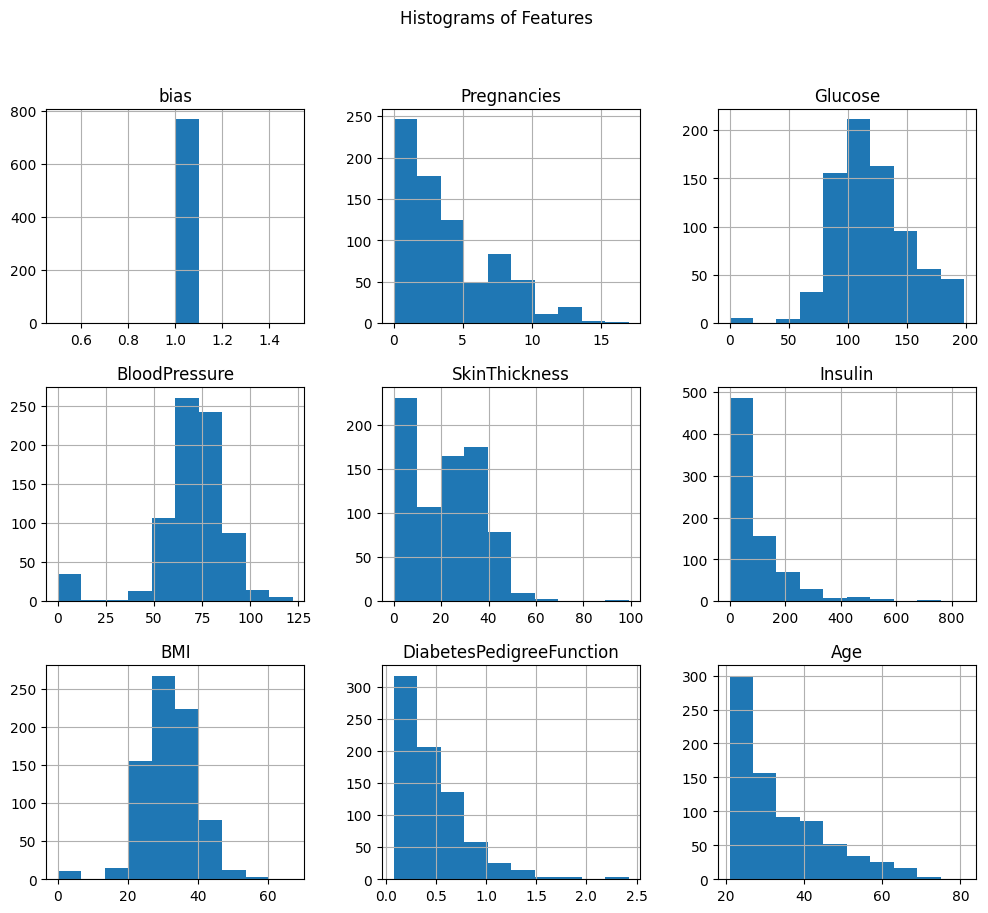

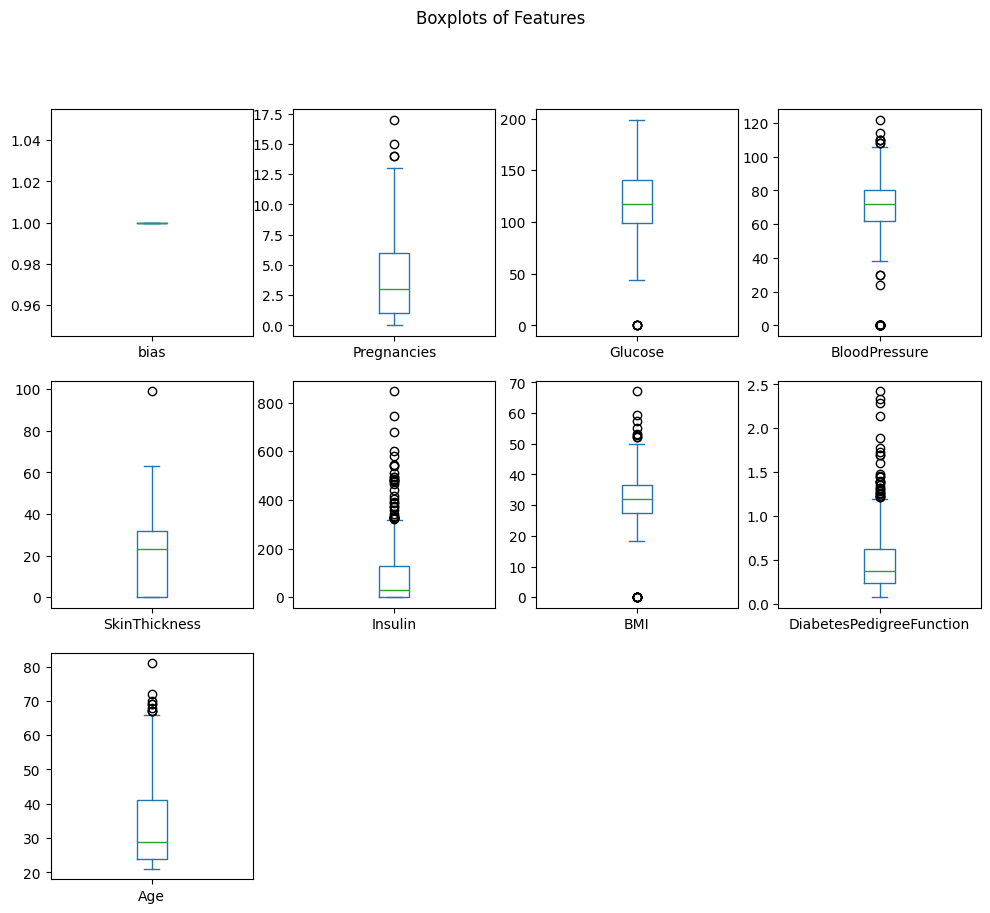

In [7]:
import matplotlib.pyplot as plt

# Histograms for all features
x.hist(figsize=(12, 10))
plt.suptitle("Histograms of Features")
plt.show()

# Boxplots for all features
x.plot(kind='box', subplots=True, layout=(3, 4), figsize=(12, 10), sharex=False, sharey=False)
plt.suptitle("Boxplots of Features")
plt.show()


### qestion 3


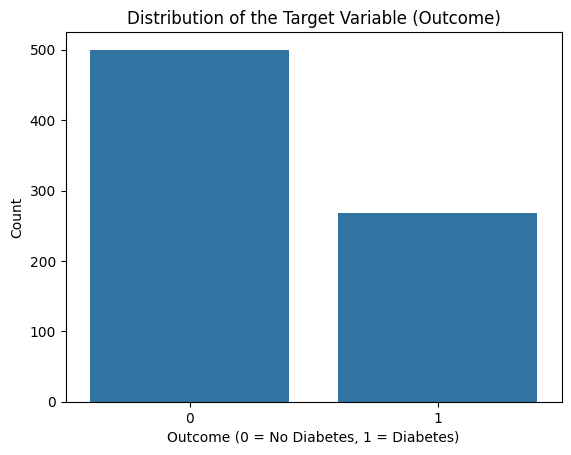

In [8]:
sns.countplot(x=y)
plt.title("Distribution of the Target Variable (Outcome)")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

### qestion 4

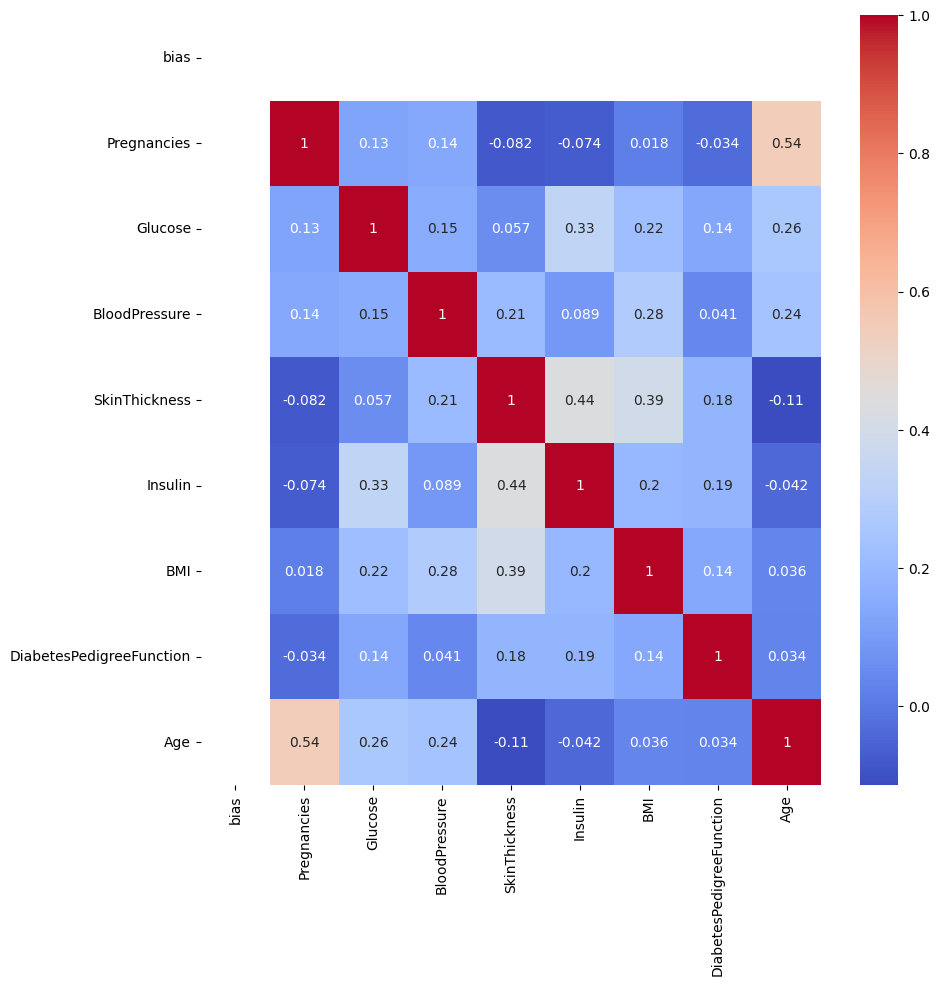

In [9]:
corr_matrix = x.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


# part 3
### qestion 1

In [10]:

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(x, y, theta):
    m = len(y)
    h = sigmoid(np.dot(x, theta))
    epsilon = 1e-15  # to avoid log(0)
    cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost
def compute_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    gradient = (1/m) * np.dot(X.T, (h - y))
    return gradient


### qestion 2

In [11]:
def gradient_descent(x,y,theta,learnig_rate,epochs,tolerance=1e-6):
    m=len(y)
    cost_history=[]
    for i in range(epochs):
        h=sigmoid(np.dot(x,theta))
        grad=(1/m)*np.dot(x.T,(h-y))
        theta = theta - learnig_rate * grad
        cost = compute_cost(x, y, theta)
        cost_history.append(cost)
        if i > 0 and abs(cost_history[-1] - cost_history[-2]) < tolerance:
            print(f"Converged at iteration {i}")
            break
    return theta,cost_history

### qestion 3

In [12]:

learning_rate = 0.01   
epochs = 10000         
theta = np.zeros((x.shape[1], 1))  


In [13]:
# Convert to NumPy arrays
X = x.values
Y = y.values.reshape(-1, 1)  # make y a column vector

theta_final, cost_history = gradient_descent(X, Y, theta, learning_rate, epochs)


In [14]:
def predict(X, theta, threshold=0.5):
    
    probabilities = sigmoid(np.dot(X, theta))

   
    predictions = (probabilities >= threshold).astype(int)

    return predictions


In [15]:
y_pred = predict(X, theta_final)
print(y_pred[:20])
df.head(10)

[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


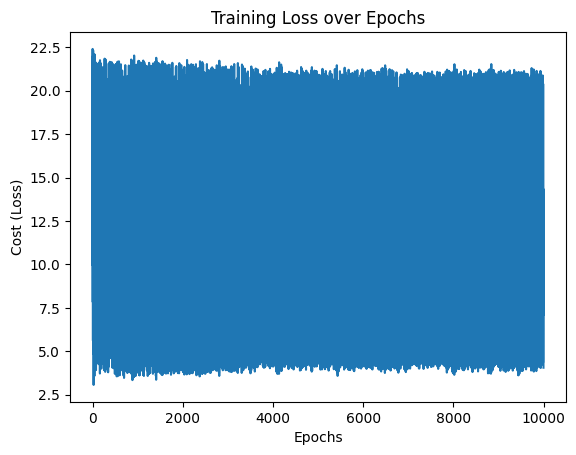

In [16]:


# Plot the loss curve
plt.plot(range(len(cost_history)), cost_history)
plt.title("Training Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost (Loss)")
plt.show()


In [ ]:

X_no_bias = x.drop('bias', axis=1, errors='ignore')  


mu = X_no_bias.mean()
sigma = X_no_bias.std()


X_normalized = (X_no_bias - mu) / sigma


X_normalized['bias'] = 1
cols = ['bias'] + [col for col in X_normalized.columns if col != 'bias']
X_normalized = X_normalized[cols]


X_normalized = X_normalized.values
y = y.values.reshape(-1, 1)
